# Type Ia Supernova Distance

A **Type Ia supernova** is a white dwarf that explodes once it nears 1.4 solar
masses. Because they all blow up under similar conditions, they all reach
*nearly* the same peak brightness. That makes them **standard candles** bright
enough to see in galaxies tens of millions of light years away.

This notebook fits a modern light-curve model (**SALT2**) to AAVSO photometry of a
supernova, turns the fit into a distance, and checks it against published
distances to the host galaxy.

| Step | We compute | From |
|---|---|---|
| 1 | Milky Way dust $E(B-V)$ | a dust map, toward the host galaxy |
| 2 | Redshift $z$ | the host galaxy's spectrum (NED) |
| 3 | Light-curve fit: $t_0, x_0, x_1, c$ | every observation, in every band |
| 4 | Peak brightness $m_B$ and true brightness $M_{\text{eff}}$ | the fit, via the Tripp estimator |
| 5 | Distance $d$ | $m_B$ and $M_{\text{eff}}$ |
| Check | Compare with published distances | NED-D |

## Background: the distance modulus

**Start with flux.** A supernova gives off a total power $L$ (its *luminosity*,
in watts) equally in every direction. At distance $d$ that light is spread over a
sphere of area $4\pi d^2$, so the **flux** $f$ we collect (watts per square metre) is

$$ f = \frac{L}{4\pi d^2} $$

This is the **inverse-square law**: twice as far away, a quarter of the light.

**Convert to magnitudes.** Astronomers measure brightness in magnitudes, a
logarithmic scale where *smaller numbers are brighter*:

$$ m = -2.5\log_{10}(f) + C $$

where $C$ is a fixed zero-point. The **absolute magnitude** $M$ is defined as the
magnitude the supernova *would* have at a standard distance of 10 parsecs, where its
flux would be $f_{10} = L / \left(4\pi\,(10\ \text{pc})^2\right)$. So $M = -2.5\log_{10}(f_{10}) + C$.

**Subtract the two.** Write both magnitudes out and subtract:

$$ m - M = \left[-2.5\log_{10}(f) + C\right] - \left[-2.5\log_{10}(f_{10}) + C\right] = -2.5\left[\log_{10}(f) - \log_{10}(f_{10})\right] $$

The zero-point $C$ cancels. Now use the first log rule, **the difference of two
logs is the log of their ratio**:

$$ \log_{10}(a) - \log_{10}(b) = \log_{10}\!\left(\frac{a}{b}\right) $$

which turns the bracket into a single log:

$$ m - M = -2.5\log_{10}\!\left(\frac{f}{f_{10}}\right) $$

This is why magnitudes are useful: a *difference* in magnitudes is a *ratio* of
fluxes.

**Work out the flux ratio.** Put in $f = L / 4\pi d^2$ and $f_{10} = L / 4\pi\,(10\ \text{pc})^2$.
The luminosity $L$ and the $4\pi$ cancel, leaving only distance (with $d$ in parsecs):

$$ \frac{f}{f_{10}} = \frac{L / 4\pi d^2}{L / 4\pi\, 10^2} = \frac{10^2}{d^2} = \left(\frac{10}{d}\right)^2 $$

That's why we never need to know the supernova's luminosity: it drops out.

**Simplify.** Substituting the ratio gives $m - M = -2.5\log_{10}\left(\frac{10}{d}\right)^2$.
Two more log rules finish the job:

- **A power comes out front:** $\log_{10}(x^n) = n\log_{10}(x)$, so
  $-2.5\log_{10}\left(\frac{10}{d}\right)^2 = -2.5 \times 2 \log_{10}\left(\frac{10}{d}\right) = -5\log_{10}\left(\frac{10}{d}\right)$
- **The log of a ratio is a difference** (the first rule, backwards), and $\log_{10}(10) = 1$, so
  $\log_{10}\left(\frac{10}{d}\right) = \log_{10}(10) - \log_{10}(d) = 1 - \log_{10}(d)$

Putting those together:

$$ m - M = -5\left[1 - \log_{10}(d)\right] = 5\log_{10}(d) - 5 $$

This is the **distance modulus**, often written $\mu = m - M$.

**Solve for $d$.** Add 5 and divide by 5 to get $\log_{10}(d)$ on its own, then undo
the log by raising 10 to both sides (since $10^{\log_{10}(x)} = x$):

$$ \log_{10}(d) = \frac{m - M + 5}{5} \qquad\Longrightarrow\qquad d = 10^{\,(m - M + 5)/5} \text{ parsecs} $$

For example, a star with $m - M = 5$ is at $d = 10^{10/5} = 10^2 = 100$ parsecs.

- $m$, the **apparent magnitude**, is how bright the supernova *looks*. We measure it.
- $M$, the **absolute magnitude**, is a property of the supernova. We can't measure it directly.

**Standard, but not quite.** Type Ia supernovae aren't all identical. In 1993
Mark Phillips found that the brighter ones fade more slowly after peak. A modern
fit measures that *stretch* ($x_1$) and the supernova's *color* ($c$, which also
picks up reddening by dust in the host galaxy), and uses both to correct $M$.

## Setup

In [1]:
import astronotebooks
astronotebooks.check_environment()   # stops here, with instructions, if Jupyter is using the wrong Python

import numpy as np
import matplotlib.pyplot as plt
import sncosmo

from astronotebooks import aavso, catalogs, plots, report, supernova
from astronotebooks.relations import TRIPP

environment OK


### Choose a supernova

Pick one of the samples in `photometry/` by setting `SUPERNOVA`. Each needs its
**host galaxy** (double-check it in NED or the discovery notice: a wrong galaxy
gives a wrong redshift).

`exclude` lists observers to set aside. Use it only when you can show an
observer's data is **consistently off from other observers on the same nights**.
Decide from the data, never from whether the final distance looks better or worse:
choosing data by the answer you expect defeats the purpose of measuring it.

For SN 2026aaiv, RNDA's points compared with other observers within the same night:

| Band | RNDA vs. others (median) | Brighter than others |
|---|---|---|
| B | −0.01 mag | 9 of 15 (normal scatter) |
| V | −0.43 mag | 21 of 21 |
| R | −0.36 mag | 18 of 18 |
| I | −0.44 mag | 6 of 6 |

B agrees, but V, R and I are 0.4 mag too bright, every time. That pattern points to
extra red light in the aperture, most likely from the host galaxy. It would make the
supernova look redder, and therefore closer, than it is.

In [2]:
TARGETS = {
    "SN 2011fe":   {"file": "photometry/2011fe.csv",   "host": "M101"},
    "SN 2011by":   {"file": "photometry/2011by.csv",   "host": "NGC 3972"},
    "SN 2012fr":   {"file": "photometry/2012fr.csv",   "host": "NGC 1365"},
    "SN 2014J":    {"file": "photometry/2014j.csv",    "host": "M82"},
    "SN 2025rbs":  {"file": "photometry/2025rbs.csv",  "host": "NGC 7331"},
    "SN 2026aaiv": {"file": "photometry/2026aaiv.csv", "host": "NGC 7331",
                    "exclude": {"RNDA": "V/R/I ~0.4 mag brighter than other observers on the same nights; B agrees"}},
}

SUPERNOVA = "SN 2026aaiv"
MY_OBSERVER = "WJRA"     # your AAVSO observer code: your points are highlighted in Step 3

target = TARGETS[SUPERNOVA]
HOST = target["host"]
print(f"{SUPERNOVA} in {HOST}: {target['file']}")

SN 2026aaiv in NGC 7331: photometry/2026aaiv.csv


## Load the observations

Read the AAVSO download and plot every band the model can use (U, B, V, R, I).
`df` keeps the download's own column names (`jd`, `mag`, `uncertainty`, `band`,
`observer`, ...) and band names ("Johnson V", "Cousins R"), as the
[AAVSO data download](https://www.aavso.org/data-download) gives them.
Set-aside observers are drawn hollow so you can see what was removed.

The fit needs a rough starting guess for the peak time, $t_0$. We use the
brightest V-band point. Only data from 10 days before to 50 days after that
guess are fit (the gray shading is left out), because that's the range the
SALT2 model was trained on.

  dropped 1 'fainter than' (non-detection) rows
  set aside 84 point(s) from excluded observer(s): RNDA
peak guess (brightest V point): JD 2461302.87


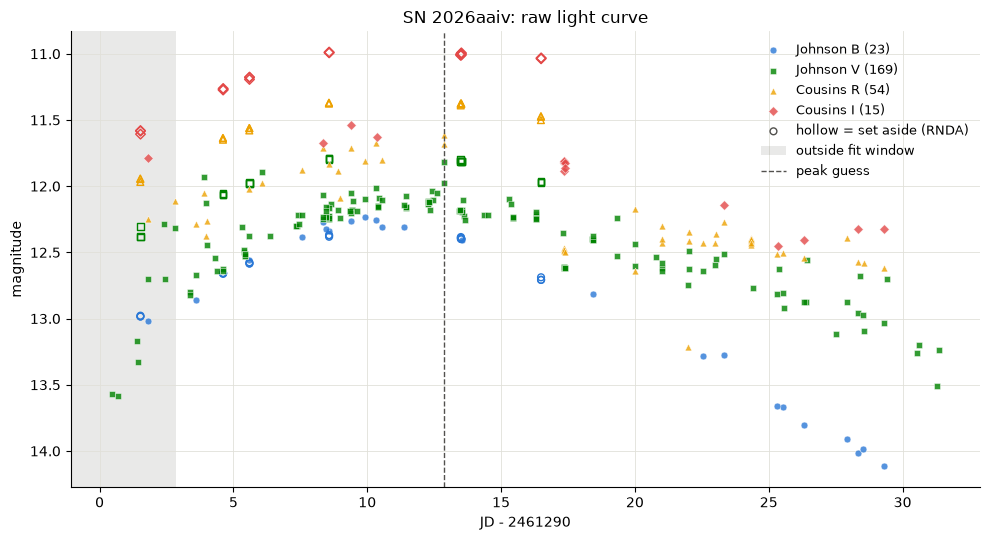

In [3]:
df_all = aavso.load_aid_download(target["file"])
df, df_excluded = aavso.split_by_observer(df_all, target.get("exclude"))

v = df[df["band"] == "Johnson V"].dropna(subset=["jd", "mag", "uncertainty"])
t0_guess = v["jd"].iloc[np.argmin(v["mag"])]
print(f"peak guess (brightest V point): JD {t0_guess:.2f}")

plots.plot_multiband(df, f"{SUPERNOVA}: raw light curve", excluded=df_excluded,
                     t0_guess=t0_guess, phase_window=supernova.PHASE_WINDOW)
plt.show()

## Step 1 · Milky Way dust

Dust in our own galaxy dims and reddens the supernova's light on its way to us.
The host galaxy is millions of parsecs away, far beyond all the Milky Way's dust,
so the **total** dust in that direction (from the NASA/IPAC dust map) is exactly
the right correction. We pass it to the fit as $E(B-V)$, the amount of reddening.

Dust inside the *host* galaxy is different: no map knows about it. The fit's
color parameter $c$ takes care of that (Step 4).

In [4]:
ebv_mw = catalogs.milky_way_ebv(HOST)
if ebv_mw is None:
    ebv_mw = 0.0
    print("dust lookup failed, using E(B-V) = 0")
print(f"Milky Way E(B-V) toward {HOST}: {ebv_mw:.3f} mag")

Milky Way E(B-V) toward NGC 7331: 0.091 mag


## Step 2 · Redshift of the host galaxy

The expansion of the universe stretches the supernova's light to longer
wavelengths by a factor $(1 + z)$. The model needs $z$ to know which part of its
spectrum lands in each of our filters. A light curve can't measure $z$ on its own,
so we take the host galaxy's redshift from its spectrum, via NED.

In [5]:
z_host = catalogs.ned_redshift(HOST)
print(f"redshift of {HOST}: z = {z_host}")

redshift of NGC 7331: z = 0.00272188301681692


## Step 3 · Fit the SALT2 light curve

We don't draw just any curve through the points. **SALT2** (Guy et al. 2007,
retrained by Brout et al. 2022) is a model of how a *normal Type Ia supernova's*
light changes over time, learned from hundreds of well-observed supernovae. The fit
can only choose from that family of supernova light curves, and it picks the one
that best matches our data.

**The model.** SALT2 describes the supernova's spectrum at every wavelength
$\lambda$ and time $t$:

$$ \text{flux}(t, \lambda) = x_0 \,\big[\, M_0(t,\lambda) + x_1\, M_1(t,\lambda) \,\big] \times e^{\,c\,\cdot\, CL(\lambda)} $$

- $M_0$ is the **average** Type Ia supernova: how its spectrum brightens and fades.
- $M_1$ is the main way real supernovae **differ** from the average. More of it
  (larger $x_1$) gives a broader light curve that fades more slowly.
- $CL(\lambda)$ is a **color law**: how much redder or bluer the light gets at
  each wavelength, scaled by $c$.

$M_0$, $M_1$ and $CL$ are fixed: they came from the training. The fit only gets
**four knobs**:

| Parameter | Meaning |
|---|---|
| $t_0$ | time of peak brightness (in B) |
| $x_0$ | overall brightness scale |
| $x_1$ | **stretch**: how slowly it fades (slower = intrinsically brighter) |
| $c$ | **color**: redder = dimmer, from the supernova itself or host-galaxy dust |

The redshift and Milky Way dust are held fixed at the values from Steps 1–2. For
each setting of the knobs, the model's spectrum is passed through each filter
(B, V, R, I) to predict what every observer should have measured.

**How it picks.** For each observation $i$, take the gap between data and model,
measured in units of that point's uncertainty $\sigma_i$, square it, and add them
all up:

$$ \chi^2 = \sum_i \left( \frac{\text{data}_i - \text{model}_i}{\sigma_i} \right)^2 $$

The fitter (`iminuit`) adjusts the four knobs until $\chi^2$ is as small as
possible. Points with small error bars count more. Every point in every band is
fit at once.

**The error floor.** Each observer's error bar usually covers only photon noise
(often just 0.003–0.01 mag). It leaves out the differences *between* observers:
filters, comparison stars, calibration. Those are typically a few hundredths of a
magnitude. Without accounting for that, the few observers quoting the tiniest error
bars dominate the fit, and dropping any one of them can swing the result. So before
fitting we add a floor to every error bar, combined in quadrature:

$$ \sigma_i^{\text{fit}} = \sqrt{\sigma_i^2 + \sigma_{\text{floor}}^2}, \qquad \sigma_{\text{floor}} = 0.03 \text{ mag} $$

A point quoted at ±0.004 mag is fit at ±0.030. A point quoted at ±0.10 barely
changes (±0.104). A floor handles *random* differences between observers. It can't
fix an observer whose data is consistently offset, which is what `exclude` is for.

**Why only four knobs?**
- **They're the numbers we need.** A free-form curve could hit every point, but
  it wouldn't give a stretch or a color. Those are what Step 4 turns into the
  supernova's true brightness.
- **The calibration belongs to this model.** The constants in Step 4 were measured
  by fitting this same model to hundreds of supernovae, so our $x_1$ and $c$ have
  to come from it too.
- **It resists noise and gaps.** The curve can't chase one bad point or invent
  wiggles where there's no data, so it can fill in times nobody observed.

**The flip side:** when the data contain something that *isn't* a normal Type Ia
supernova (light from the host galaxy in the photometry aperture, or unusual dust),
the model can't bend to match it. It settles on the best compromise, and the
mismatch shows up in the band-by-band plots below. That misfit is useful: it's a sign something
in the data isn't a normal supernova.

First, the AAVSO magnitudes are converted to flux, since that's what the model
works in. The library helper also drops any band with too few points to
constrain the light-curve shape.

In [6]:
ERROR_FLOOR = 0.03   # mag, added in quadrature to every error bar (set 0 to see the difference)

df_fit = df.assign(uncertainty=np.sqrt(df["uncertainty"]**2 + ERROR_FLOOR**2))
photdata = supernova.build_photometry_table(df_fit, t0_guess)
print(f"fitting {len(photdata)} points in bands {sorted(set(photdata['band']))}, error floor {ERROR_FLOOR} mag")

model = sncosmo.Model(source=sncosmo.get_source("salt2", version="B22"),
                      effects=[sncosmo.F99Dust()], effect_names=["mw"], effect_frames=["obs"])
model.set(z=z_host, mwebv=ebv_mw, t0=t0_guess)

bounds = {"x1": (-5, 5), "c": (-2, 2)}
result, fit = sncosmo.fit_lc(photdata, model, ["t0", "x0", "x1", "c"], bounds=bounds)

x1, x1_err = fit.get("x1"), result.errors["x1"]
c, c_err = fit.get("c"), result.errors["c"]
print(f"t0 = JD {fit.get('t0'):.2f}")
print(f"x1 = {x1:+.3f} ± {x1_err:.3f}   (stretch)")
print(f"c  = {c:+.3f} ± {c_err:.3f}   (color)")
supernova.check_fit(photdata, fit, bounds)

fitting 249 points in bands [np.str_('bessellb'), np.str_('besselli'), np.str_('bessellr'), np.str_('bessellv')], error floor 0.03 mag
t0 = JD 2461300.39
x1 = -1.325 ± 0.060   (stretch)
c  = +0.154 ± 0.007   (color)
  fit looks healthy (peak inside the data, no parameter at its limit)


True

### A closer look, one band at a time

Now we compare the fitted model with the observations, one filter at a time.
Each band gets a plot and a table.

**The plot.**
- **Top:** the model light curve in that filter (the same four knobs in every band),
  with every observation the fit used. Brighter is up. The star marks the model's
  peak in this band. The dotted line at day 0 is the B-band peak $t_0$.
  Points from `MY_OBSERVER` are drawn larger, in black, and labeled.
- **Bottom:** each point's **distance from the curve**, data − model, in
  magnitudes. Points above the line are brighter than the model, points below are
  fainter. The gray strip is ±0.05 mag.

**The table**, one row per observer:

| Column | Meaning |
|---|---|
| Points, First/Last day | how many observations, and when (days from $t_0$) |
| Offset | median distance from the curve (negative = brighter than the model) |
| Scatter | how much the observer's points vary around their own offset |
| Quoted error | the typical error bar the observer reported |
| Typical \|pull\| | distance from the curve divided by the observer's *quoted* error bar (before the floor). About 1 if the error bars are honest. |

**What to look for.**
- **Small offsets of a few hundredths of a magnitude are normal.** Every observer
  has slightly different filters, comparison stars and calibration.
- **An offset much bigger than everyone else's** points to something specific to
  that observer: their aperture, their comparison stars, or a transform problem.
- **An offset that grows as the supernova fades** is the fingerprint of *constant*
  extra light, usually the host galaxy inside the photometry aperture. The galaxy
  adds the same flux every night, so it matters more and more as the supernova
  gets fainter.
- **A large |pull| with a small scatter** means the observer's error bars are much
  smaller than their real offset from everyone else.

In [7]:
res = supernova.fit_residuals(df, fit, photdata, t0_guess)
print(f"{len(res)} observations from {res['observer'].nunique()} observers, "
      f"in bands {', '.join(sorted(res['band'].unique()))}")

249 observations from 23 observers, in bands Cousins I, Cousins R, Johnson B, Johnson V


#### B band

The bluest band, and the one the peak brightness $m_B$ (Step 4) is measured in.
Together with V, it sets the color $c$. B fades fastest after peak.

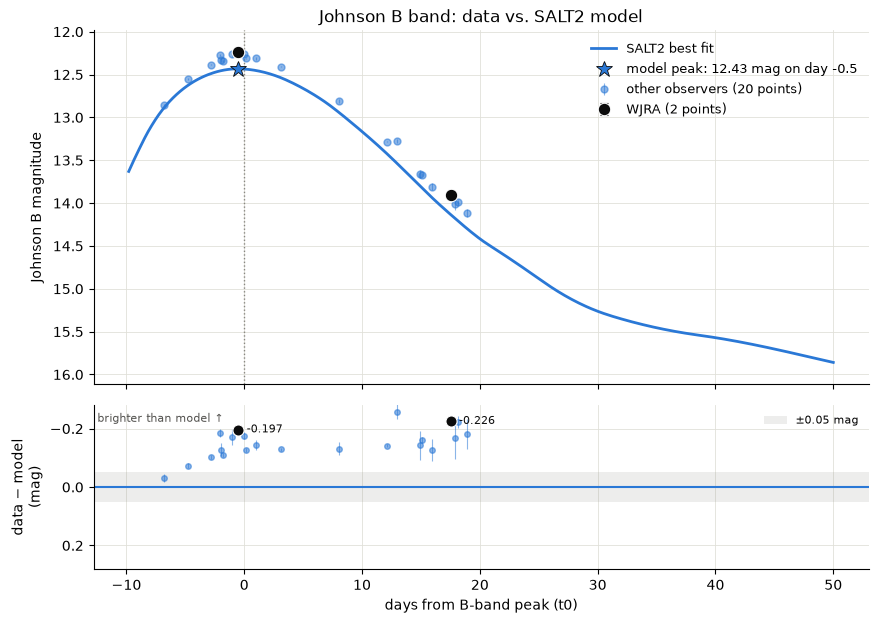

Observer,Points,First day,Last day,Offset (mag),Scatter (mag),Quoted error (mag),Typical |pull|
CDZ,8,-6.8,+18.1,-0.119,0.058,0.009,13.3
DUBF,8,-2.1,+18.9,-0.174,0.039,0.032,5.1
AANE,3,-1.9,+8.1,-0.131,0.008,0.022,5.9
WJRA,2,-0.5,+17.5,-0.211,0.020,0.007,35.9
RTH,1,+3.1,+3.1,-0.129,–,0.006,21.6


In [8]:
plots.plot_band_fit(res, fit, "Johnson B", MY_OBSERVER)
plt.show()
report.observer_fit_table(res, "Johnson B", MY_OBSERVER)

#### V band

Usually the band with the most observations, so it's the best place to see how
different observers compare with each other on the same nights.

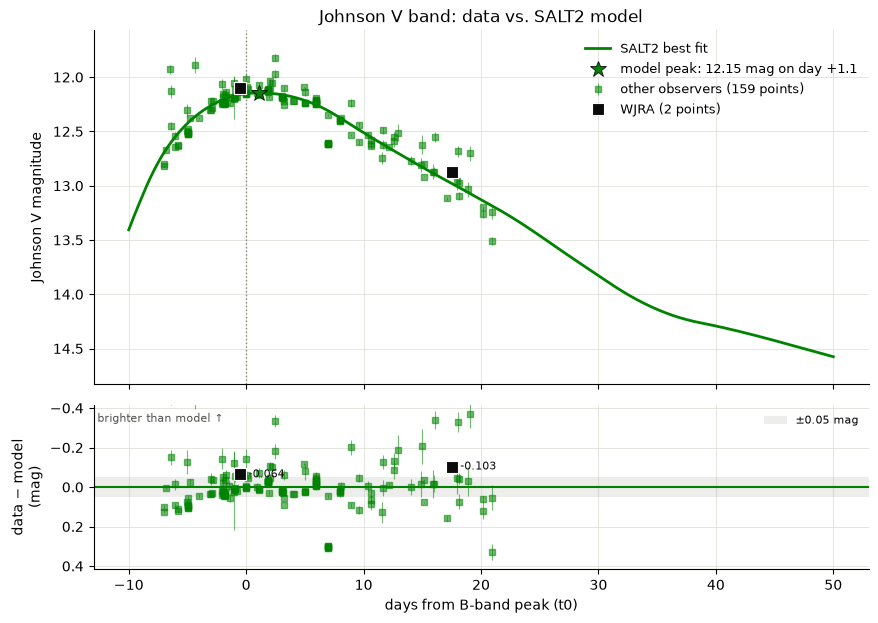

showing the 15 observers with the most Johnson V points (of 23), plus WJRA


Observer,Points,First day,Last day,Offset (mag),Scatter (mag),Quoted error (mag),Typical |pull|
ATE,23,-2.9,+8.0,+0.019,0.010,0.011,1.3
SSKB,18,-6.5,+12.6,-0.067,0.231,0.035,3.1
PYG,12,-3.0,+20.2,-0.045,0.060,0.030,2.0
SDI,12,-5.8,+17.1,+0.100,0.025,0.009,11.8
LMAN,10,+5.9,+5.9,-0.026,0.017,0.014,1.5
BKL,10,-1.9,-1.8,+0.037,0.005,0.003,12.3
PACA,10,+1.9,+1.9,-0.026,0.006,0.010,2.6
CEM,9,-7.0,+8.9,+0.045,0.031,0.010,4.5
DUBF,8,-2.1,+18.9,-0.085,0.069,0.069,1.5
BXV,8,-7.0,+4.0,+0.036,0.034,0.010,3.6


In [9]:
plots.plot_band_fit(res, fit, "Johnson V", MY_OBSERVER)
plt.show()
report.observer_fit_table(res, "Johnson V", MY_OBSERVER)

#### R band

Galaxy light is redder than a supernova at peak, so contamination from the host
galaxy shows up more strongly here than in B or V. Check whether the points sit
consistently above the curve.

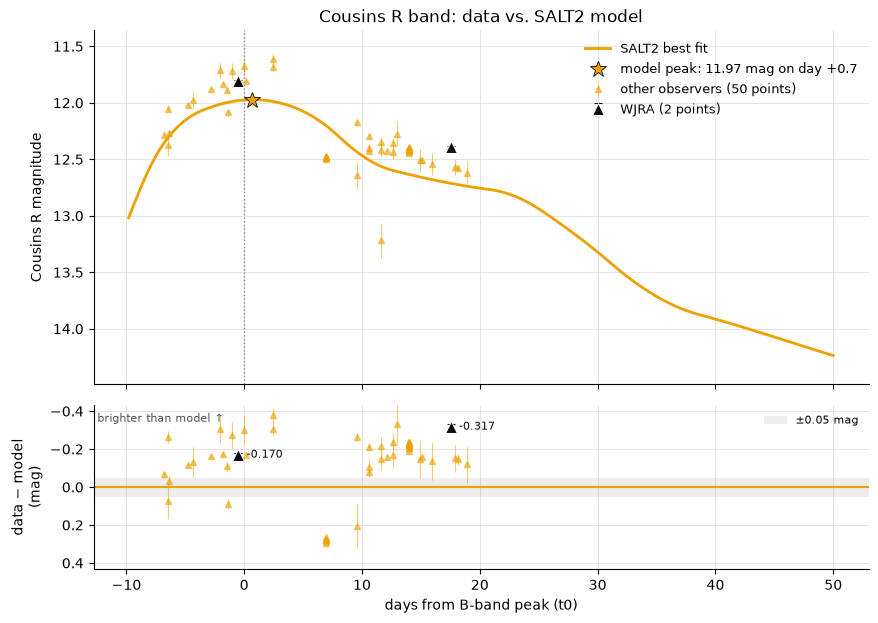

Observer,Points,First day,Last day,Offset (mag),Scatter (mag),Quoted error (mag),Typical |pull|
SSKB,18,-6.5,+12.6,-0.139,0.237,0.040,3.7
LMAN,10,+14.0,+14.0,-0.223,0.015,0.015,14.3
CDZ,8,-6.8,+18.1,-0.158,0.036,0.010,16.5
DUBF,8,-2.1,+18.9,-0.212,0.090,0.086,2.6
PIV,6,+7.0,+7.0,+0.277,0.011,0.008,33.6
WJRA,2,-0.5,+17.5,-0.244,0.104,0.013,18.8


In [10]:
plots.plot_band_fit(res, fit, "Cousins R", MY_OBSERVER)
plt.show()
report.observer_fit_table(res, "Cousins R", MY_OBSERVER)

#### I band

The model's curve shows a **second maximum** around 20–25 days after peak: Type Ia
supernovae really do re-brighten in the red and near-infrared a few weeks after
maximum. Galaxy light affects I even more than R. Fewer amateurs observe in I, so
this band often has the fewest points.

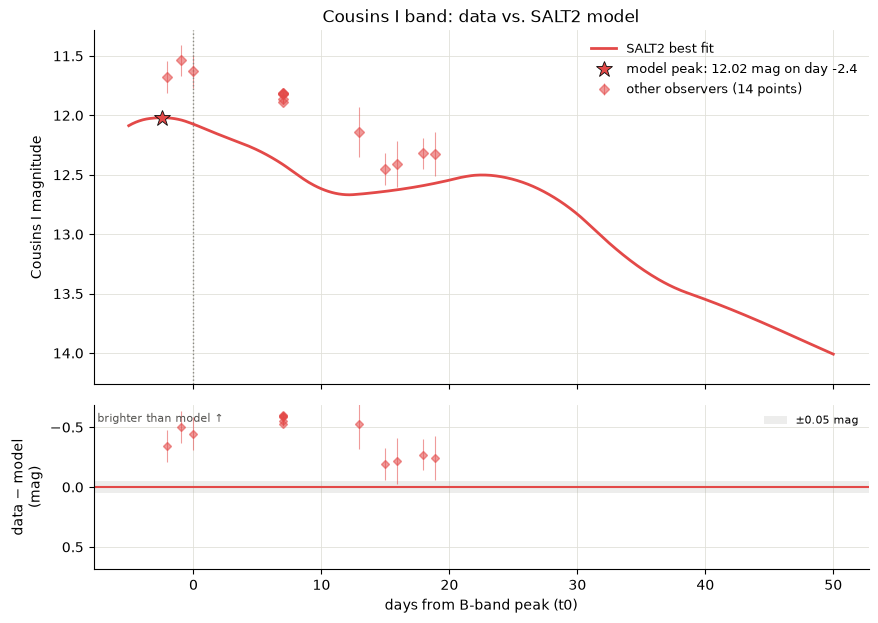

Observer,Points,First day,Last day,Offset (mag),Scatter (mag),Quoted error (mag),Typical |pull|
DUBF,8,-2.1,+18.9,-0.307,0.132,0.137,2.3
PIV,6,+7.0,+7.0,-0.590,0.030,0.014,40.9


In [11]:
plots.plot_band_fit(res, fit, "Cousins I", MY_OBSERVER)
plt.show()
report.observer_fit_table(res, "Cousins I", MY_OBSERVER)

## Step 4 · Peak brightness and the Tripp estimator

**Apparent peak brightness $m_B$.** We ask the fitted model for its B-band
magnitude at peak.

**True brightness $M_{\text{eff}}$.** The **Tripp estimator** corrects a standard
peak brightness $M_B^0$ for stretch and color:

$$ M_{\text{eff}} = M_B^0 - \alpha\, x_1 + \beta\, c $$

- A slow fader ($x_1 > 0$) is intrinsically brighter, so $M$ gets smaller (brighter).
- A red supernova ($c > 0$) is dimmer, so $M$ gets larger (fainter). This is how
  host-galaxy dust gets corrected.

$\alpha$, $\beta$ and $M_B^0$ were measured from many hundreds of supernovae and
can't be fit from just one. We use the Pantheon+ values (Brout et al. 2022), with
$M_B^0$ anchored to Cepheid distances by SH0ES (Riess et al. 2022).

The uncertainty includes the fit errors on $x_1$ and $c$, the uncertainties on
$\alpha$, $\beta$ and $M_B^0$, and the **0.17 mag scatter** real supernovae show
around the relation even after correction.

In [12]:
t = TRIPP
m_B = fit.source_peakmag("bessellb", "vega")

M_eff = t["M_B0"] - t["alpha"] * x1 + t["beta"] * c
M_eff_err = np.sqrt((x1 * t["alpha_err"])**2 + (t["alpha"] * x1_err)**2
                    + (c * t["beta_err"])**2 + (t["beta"] * c_err)**2
                    + t["M_B0_err"]**2 + t["rms"]**2)

print(f"calibration: alpha = {t['alpha']}, beta = {t['beta']}, M_B0 = {t['M_B0']}  ({t['label']})")
print(f"m_B   (apparent peak) : {m_B:.3f}")
print(f"M_eff (true peak)     : {M_eff:.3f} ± {M_eff_err:.3f}")

calibration: alpha = 0.148, beta = 3.09, M_B0 = -19.253  (SALT2-B22 + Pantheon+/SH0ES)
m_B   (apparent peak) : 12.061
M_eff (true peak)     : -18.581 ± 0.175


## Step 5 · Distance

Into the distance modulus. An uncertainty $\sigma$ in magnitudes becomes a
*fractional* distance uncertainty: $\sigma_d = d \cdot \frac{\ln 10}{5} \cdot \sigma$.

In [13]:
PC_TO_LY = 3.2616   # light years per parsec


def distance_from_modulus(m, M, M_err):
    d = 10 ** ((m - M + 5) / 5)
    d_err = d * np.log(10) / 5 * M_err
    return d, d_err


d_pc, d_err = distance_from_modulus(m_B, M_eff, M_eff_err)
d_mpc, d_err_mpc = d_pc / 1e6, d_err / 1e6

print(f"distance modulus mu = {m_B - M_eff:.3f}")
print(f"distance = {d_mpc:.2f} ± {d_err_mpc:.2f} Mpc  ({d_mpc * PC_TO_LY:.1f} ± {d_err_mpc * PC_TO_LY:.1f} million light years)")

distance modulus mu = 30.642
distance = 13.44 ± 1.08 Mpc  (43.8 ± 3.5 million light years)


## Check against published distances

**NED-D** is NASA/IPAC's collection of every published distance to a galaxy. We
compare against two summaries of it:

- **All:** every paper, every method. This shows how much the literature itself
  disagrees.
- **Refined:** only the most direct methods: Cepheids, the tip of the red giant
  branch (TRGB), surface brightness fluctuations (SBF), and planetary nebulae
  (PNLF), with outliers removed. This is the one that counts.

Tully-Fisher distances are left out of "refined" because most of them assume an
outdated Hubble constant and read 20–30% short. Supernova-based distances are
left out because they could be measurements of this very supernova.

**How close is close enough?** We measure the gap between our distance and NED-D's
in units of their **combined uncertainty**, $\sigma = \sqrt{\sigma_{\text{ours}}^2 + \sigma_{\text{NED}}^2}$:

| Gap | Verdict | How often a *correct* measurement lands here by chance |
|---|---|---|
| within 1σ | **agrees** | about 68% of the time |
| 1σ to 2σ | **consistent** | about 27% of the time |
| beyond 2σ | **disagrees** | only about 5% of the time: worth investigating |

A strict "within 1σ or fail" test would flag about a third of perfectly good
measurements. "Consistent" means the difference is the normal size you'd expect
from the uncertainties; "disagrees" means something is probably wrong.

NED-D refined: 14.86 ± 0.85 Mpc from 9 papers (4 outliers removed)
NED-D all    : 13.54 ± 2.86 Mpc from 33 papers
this notebook: 13.44 ± 1.08 Mpc (-9.5% vs. refined)
gap vs. refined: 1.03σ  ->  consistent


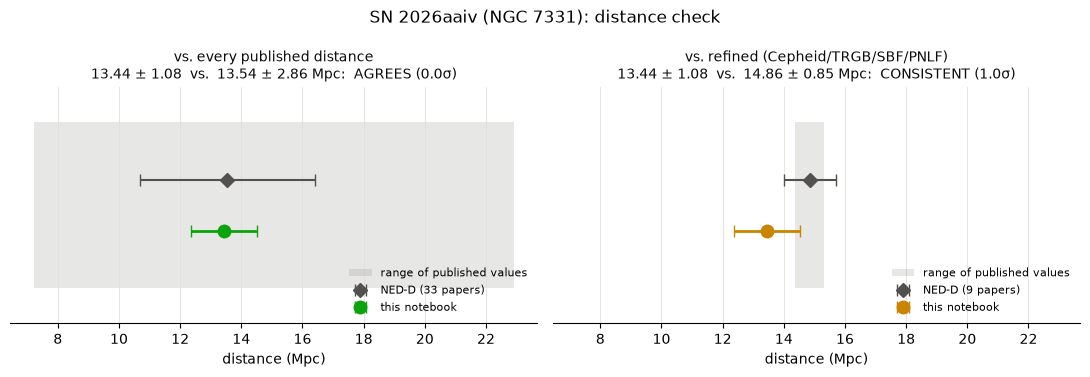

In [14]:
ned = catalogs.ned_distances(HOST)

if ned:
    r = ned["refined"]
    print(f"NED-D refined: {r['d_mpc']:.2f} ± {r['d_err_mpc']:.2f} Mpc from {r['n']} papers "
          f"({r['n_clipped']} outliers removed)")
    print(f"NED-D all    : {ned['all']['d_mpc']:.2f} ± {ned['all']['d_err_mpc']:.2f} Mpc from {ned['all']['n']} papers")
    print(f"this notebook: {d_mpc:.2f} ± {d_err_mpc:.2f} Mpc ({100 * (d_mpc - r['d_mpc']) / r['d_mpc']:+.1f}% vs. refined)")

    n_sigma, tier = report.agreement(d_mpc, d_err_mpc, r["d_mpc"], r["d_err_mpc"])
    print(f"gap vs. refined: {n_sigma:.2f}σ  ->  {tier}")

    plots.plot_distance_check(d_mpc, d_err_mpc, ned, f"{SUPERNOVA} ({HOST}): distance check")
    plt.show()

## Notes on the sample supernovae

| Supernova | Host | Notes |
|---|---|---|
| SN 2011fe | M101 | Very well observed and nearby. A good first run. |
| SN 2011by | NGC 3972 | NED-D has only one refined distance for this galaxy. |
| SN 2012fr | NGC 1365 | |
| SN 2014J | M82 | **Expected to fail.** M82's dust is unusual ($R_V \approx 1.4$ instead of the normal 3.1; Amanullah et al. 2014), and the single color correction $\beta$ can't handle a different kind of dust. |
| SN 2025rbs | NGC 7331 | |
| SN 2026aaiv | NGC 7331 | Same galaxy as 2025rbs. Needs the RNDA exclusion (see Setup). Still being observed: the data stop about 20 days after peak, so stretch and color are less certain than for the others. Re-download from AAVSO as more data arrive. |

**Approximations to be aware of.** The model's standard Bessell filter curves
stand in for each observer's actual filters. Amateur photometry from many
observers also carries small offsets between them. Both add a little error that
isn't included in the uncertainty above.